# Plot results for offline prompting in the "farm" example

In [2]:
%cd ..
%pwd  # should be "llm-adaptation"

C:\Users\micha\OneDrive - Univerzita Karlova\research\2024-LLM-DEECo\llm-adaptation


'C:\\Users\\micha\\OneDrive - Univerzita Karlova\\research\\2024-LLM-DEECo\\llm-adaptation'

In [18]:
from pathlib import Path
import pandas as pd
import shutil
import subprocess
import sys
import json
import matplotlib.pyplot as plt
from matplotlib.markers import MarkerStyle
from matplotlib.ticker import FixedFormatter, FixedLocator
import numpy as np
import seaborn as sns
import os

In [19]:
results_folder = Path("generated_adaptations/farm")
# results_folder = Path("generated_adaptations/old/251015/farm")
pd.options.display.float_format = "{:,.1f}".format
sns.set_theme()

## Run experiments

In [4]:
prompts = {
    # "default": "generated_adaptations/prompts_user/farm_strategy.md",
    "coverage": "generated_adaptations/prompts_user/farm_strategy.md",
    # "state": "generated_adaptations/prompts_user/farm_strategy_state.md",
    "reasons": "generated_adaptations/prompts_user/farm_reasons.md",
}
variants = {
    "system": "system",
    "constraints": "all",
    # "stats": "stats",
    "result": "result",
}
llms = {
    # "5nanolow": "gpt-5-nano-2025-08-07,reasoning_effort=low",
    "5nano": "gpt-5-nano-2025-08-07",
    "5mini": "gpt-5-mini-2025-08-07",
    # "5": "gpt-5-2025-08-07",
}
repeats = 5
start = 1

In [5]:
# import generated_adaptations.generator as generator

In [5]:
env = os.environ.copy()
env["PYTHONPATH"] = env.get("PYTHONPATH", "") + os.pathsep + os.getcwd()

for prompt_name, prompt in prompts.items():
    for variant, mode in variants.items():
        for llm_name, llm in llms.items():
            for repeat in range(start, start + repeats):
                folder_name = f"{llm_name}_{repeat:02d}"
                print(f"\n{variant}_{prompt_name}/{folder_name}\n")
                folder = results_folder / f"{variant}_{prompt_name}" / folder_name
                folder.mkdir(parents=True, exist_ok=True)
                shutil.copy(prompt, folder / "01_user.md")
                cmd  = [sys.executable, "generated_adaptations/generator.py", f"--folder={str(folder)}", f"--llm={llm}", f"--mode={mode}"]
                result = subprocess.run(cmd, capture_output=True, text=True, env=env)  # even capture_output=False does not stream in real-time, so we rather capture it and print it later
                print(result.stdout)
                print(result.stderr)
                # generator.main([f"--folder={str(folder)}"])  # this also does not show the real-time output


system_coverage/5nano_01

Loaded 22 messages from generated_adaptations\farm\system_coverage\5nano_01.
Error: experiment in generated_adaptations\farm\system_coverage\5nano_01 was already ran. Aborting.



system_coverage/5nano_02

Loaded 22 messages from generated_adaptations\farm\system_coverage\5nano_02.
Error: experiment in generated_adaptations\farm\system_coverage\5nano_02 was already ran. Aborting.



system_coverage/5nano_03

Loaded 22 messages from generated_adaptations\farm\system_coverage\5nano_03.
Error: experiment in generated_adaptations\farm\system_coverage\5nano_03 was already ran. Aborting.



system_coverage/5nano_04

Loaded 17 messages from generated_adaptations\farm\system_coverage\5nano_04.
Error: experiment in generated_adaptations\farm\system_coverage\5nano_04 was already ran. Aborting.



system_coverage/5nano_05

Loaded 22 messages from generated_adaptations\farm\system_coverage\5nano_05.
Error: experiment in generated_adaptations\farm\system_coverage\5nano_05

## Results

In [21]:
folders = list(results_folder.glob("*/*"))
# folders = list(results_folder.glob("41mini_*"))
# folders = list(results_folder.glob("*/5nanolow*"))
# folders = [results_folder / "41mini"]

folders = [f for f in folders if "mock" not in f.parent.stem]
print([(f.parent.stem, f.stem) for f in folders])

[('constraints_coverage', '5mini_01'), ('constraints_coverage', '5mini_02'), ('constraints_coverage', '5mini_03'), ('constraints_coverage', '5mini_04'), ('constraints_coverage', '5mini_05'), ('constraints_coverage', '5nano_01'), ('constraints_coverage', '5nano_02'), ('constraints_coverage', '5nano_03'), ('constraints_coverage', '5nano_04'), ('constraints_coverage', '5nano_05'), ('constraints_reasons', '5mini_01'), ('constraints_reasons', '5mini_02'), ('constraints_reasons', '5mini_03'), ('constraints_reasons', '5mini_04'), ('constraints_reasons', '5mini_05'), ('constraints_reasons', '5nano_01'), ('constraints_reasons', '5nano_02'), ('constraints_reasons', '5nano_03'), ('constraints_reasons', '5nano_04'), ('constraints_reasons', '5nano_05'), ('result_coverage', '5mini_01'), ('result_coverage', '5mini_02'), ('result_coverage', '5mini_03'), ('result_coverage', '5mini_04'), ('result_coverage', '5mini_05'), ('result_coverage', '5nano_01'), ('result_coverage', '5nano_02'), ('result_coverage'

In [22]:
summary = pd.DataFrame(columns=["llm", "params", "repeat"])

for folder in folders:
    llm, repeat = folder.stem.split("_")
    params = folder.parent.stem
    summary.loc[len(summary), ["llm", "params", "repeat"]] = [llm, params, repeat]

    for file in (folder / "results").glob("*.txt"):
        name = file.stem.removeprefix("code_")
        code = name.split("_")[0]
        if "_missing" in name:
            summary.loc[len(summary) - 1, code + "_system"] = "missing"
        elif "_system_fail" in name:
            summary.loc[len(summary) - 1, code + "_system"] = "fail"
        elif "_system_pass" in name:
            summary.loc[len(summary) - 1, code + "_system"] = "pass"
        elif "_all_fail" in name:
            summary.loc[len(summary) - 1, code + "_all"] = "fail"
        elif "_all_pass" in name:
            summary.loc[len(summary) - 1, code + "_all"] = "pass"
        elif "_functional_fail" in name:
            summary.loc[len(summary) - 1, code + "_functional"] = "fail"
        elif "_functional_pass" in name:
            summary.loc[len(summary) - 1, code + "_functional"] = "pass"
        else:
            print(f"Unknown file: {file}")
    for file in (folder / "results").glob("*.json"):
        name = file.stem.removeprefix("code_")
        if "_simulation_result" in name:
            code = name.removesuffix("_simulation_result")
            results = json.load(open(file))
            result = results["damage"]
            summary.loc[len(summary) - 1, code + "_result"] = result
        else:
            print(f"Unknown file: {file}")
summary.fillna("", inplace=True)

C:\Users\micha\AppData\Local\Temp\ipykernel_27856\473530000.py:36: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  summary.fillna("", inplace=True)


In [23]:
summary.set_index(["llm", "params", "repeat"], inplace=True)

In [24]:
summary = summary.reindex(sorted(summary.columns), axis=1)

In [25]:
summary

02_all 02_functional 02_result 02_system  \
llm   params               repeat                                            
5mini constraints_coverage 01       fail          fail     134.7      pass   
                           02       fail          fail     127.0      pass   
                           03       fail          fail     127.0      pass   
                           04       fail          fail     129.7      pass   
                           05       fail          fail     127.0      pass   
5nano constraints_coverage 01       fail          fail     146.0      pass   
                           02       fail          fail     127.0      pass   
                           03       fail          fail     127.0      pass   
                           04       fail          fail     241.7      fail   
                           05       fail          fail     127.0      pass   
5mini constraints_reasons  01       fail          fail     224.3      pass   
                           02       pass          pass      50.3      pass   
                           03       pass          pass      37.0      pass   
                           04       pass          pass      51.3      pass   
                           05       pass          pass      54.3      pass   
5nano constraints_reasons  01       fail          fail     307.0      pass   
                           02       pass          pass     124.3      pass   
                           03       fail          fail     155.0      pass   
                           04       pass          pass      50.7      pass   
                           05       pass          pass     106.7      pass   
5mini result_coverage      01       fail          fail     127.0      pass   
                           02       fail          fail      97.7      pass   
                           03       fail          fail     127.0      pass   
                           04       fail          fail     120.0      pass   
                           05       fail          fail     127.0      pass   
5nano result_coverage      01       fail          fail     127.0      pass   
                           02       fail          fail     129.7      pass   
                           03       fail          fail     129.7      pass   
                           04       fail          fail     129.7      fail   
                           05       fail          fail      68.7      fail   
5mini result_reasons       01       pass          pass      51.3      pass   
                           02       pass          pass      46.3      pass   
                           03       fail          fail     141.3      pass   
                           04       fail          fail      45.3      pass   
                           05       fail          fail     134.0      pass   
5nano result_reasons       01       pass          pass      50.7      pass   
                           02       pass          pass      37.0      pass   
                           03       fail          fail                fail   
                           04       fail          pass      52.7      fail   
                           05       fail          fail     286.7      pass   
5mini system_coverage      01       fail          fail     127.0      pass   
                           02       fail          fail     127.0      pass   
                           03       fail          fail     149.0      pass   
                           04       fail          fail     284.3      pass   
                           05       fail          fail     129.7      pass   
5nano system_coverage      01       fail          fail     182.7      pass   
                           02       fail          fail     111.0      fail   
                           03       fail          fail     129.7      pass   
                           04       fail          fail     129.7      pass   
                           05       fail          fail  

### Plot

In [26]:
colors = {
    "5nano/constraints": "tab:blue",
    "5nano/system": "tab:green",
    "5nano/result": "tab:orange",
    "5nano/stats": "tab:red",
}
colors = {
    "5nano/constraints_state": "tab:blue",
    "5nano/constraints_default": "tab:cyan",
    "5nano/system_state": "tab:green",
    "5nano/system_default": "tab:olive",
    "5nano/result_state": "tab:orange",
    "5nano/result_default": "tab:brown",
    "5nano/stats_state": "tab:red",
    "5nano/stats_default": "tab:pink",
}
colors = {
    "5nano/constraints_default": "tab:blue",
    "5mini/constraints_default": "tab:cyan",
    "5nano/system_default": "tab:green",
    "5mini/system_default": "tab:olive",
    "5nano/result_default": "tab:orange",
    "5mini/result_default": "tab:brown",
    # "5nano/stats_default": "tab:red",
    # "5mini/stats_default": "tab:pink",
    "5nano/constraints_coverage": "tab:blue",
    "5mini/constraints_coverage": "tab:cyan",
    "5nano/system_coverage": "tab:green",
    "5mini/system_coverage": "tab:olive",
    "5nano/result_coverage": "tab:orange",
    "5mini/result_coverage": "tab:brown",
}

In [27]:
result_cols = [col for col in summary.columns if col.endswith("_result")]
plot_data = summary[result_cols].replace({"": np.nan}).astype(float)
plot_data

C:\Users\micha\AppData\Local\Temp\ipykernel_27856\65529393.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  plot_data = summary[result_cols].replace({"": np.nan}).astype(float)


02_result  04_result  06_result  08_result  \
llm   params               repeat                                               
5mini constraints_coverage 01          134.7       54.3        NaN        NaN   
                           02          127.0        NaN        NaN       83.0   
                           03          127.0      115.7       31.3       50.0   
                           04          129.7       71.3      140.3       51.0   
                           05          127.0      202.0       54.3        NaN   
5nano constraints_coverage 01          146.0      146.0      100.3      146.0   
                           02          127.0       53.3        NaN        NaN   
                           03          127.0      202.0      134.0      202.0   
                           04          241.7      110.7      299.7      299.7   
                           05          127.0      129.7       50.7        NaN   
5mini constraints_reasons  01          224.3       61.3       38.3        NaN   
                           02           50.3        NaN        NaN        NaN   
                           03           37.0        NaN        NaN        NaN   
                           04           51.3        NaN        NaN        NaN   
                           05           54.3        NaN        NaN        NaN   
5nano constraints_reasons  01          307.0      116.7      116.7      116.7   
                           02          124.3      124.3       98.7       98.7   
                           03          155.0       54.3        NaN        NaN   
                           04           50.7        NaN        NaN        NaN   
                           05          106.7       99.0      106.7       99.0   
5mini result_coverage      01          127.0       40.7        NaN        NaN   
                           02           97.7       49.0        NaN        NaN   
                           03          127.0      147.3        NaN        NaN   
                           04          120.0       33.3       54.7        NaN   
                           05          127.0      119.3      119.7       70.3   
5nano result_coverage      01          127.0      225.7      248.0       43.7   
                           02          129.7      276.0      270.0      288.3   
                           03          129.7      129.7       53.7      266.0   
                           04          129.7      225.7      248.0      203.0   
                           05           68.7      350.3      294.7      300.3   
5mini result_reasons       01           51.3        NaN        NaN        NaN   
                           02           46.3        NaN        NaN        NaN   
                           03          141.3      163.7      164.3      148.7   
                           04           45.3       51.3        NaN        NaN   
                           05          134.0      264.7        NaN      160.0   
5nano result_reasons       01           50.7        NaN        NaN        NaN   
                           02           37.0        NaN        NaN        NaN   
                           03            NaN        NaN        NaN        NaN   
                           04           52.7       46.7        NaN        NaN   
                           05          286.7      286.7      286.7      112.0   
5mini system_coverage      01          127.0        NaN        NaN        NaN   
                           02          127.0       72.0        NaN        NaN   
                           03          149.0      178.0      149.3        NaN   
                           04          284.3      279.7        NaN        NaN   
                           05          129.7       57.0        NaN        NaN   
5nano system_coverage      01          182.7      243.7      200.7      200.7   
                           02          111.0       69.0       69.0       69.0   
                           03          129.7       52.7      225.7

In [28]:
stop_by_constraints = plot_data.copy()

def clear_after_pass(row):
    passed = False

    for col in row.index:
        if not passed:
            constraints_col = col.replace('_result', '_all')
            if summary.loc[row.name, constraints_col] == "pass":
                passed = True
        else:
            row[col] = np.nan
    return row

stop_by_constraints = stop_by_constraints.apply(clear_after_pass, axis=1)
plot_data = stop_by_constraints
stop_by_constraints

02_result  04_result  06_result  08_result  \
llm   params               repeat                                               
5mini constraints_coverage 01          134.7       54.3        NaN        NaN   
                           02          127.0        NaN        NaN       83.0   
                           03          127.0      115.7        NaN        NaN   
                           04          129.7       71.3        NaN        NaN   
                           05          127.0      202.0       54.3        NaN   
5nano constraints_coverage 01          146.0      146.0      100.3      146.0   
                           02          127.0       53.3        NaN        NaN   
                           03          127.0      202.0      134.0      202.0   
                           04          241.7      110.7      299.7      299.7   
                           05          127.0      129.7       50.7        NaN   
5mini constraints_reasons  01          224.3       61.3        NaN        NaN   
                           02           50.3        NaN        NaN        NaN   
                           03           37.0        NaN        NaN        NaN   
                           04           51.3        NaN        NaN        NaN   
                           05           54.3        NaN        NaN        NaN   
5nano constraints_reasons  01          307.0      116.7        NaN        NaN   
                           02          124.3        NaN        NaN        NaN   
                           03          155.0       54.3        NaN        NaN   
                           04           50.7        NaN        NaN        NaN   
                           05          106.7        NaN        NaN        NaN   
5mini result_coverage      01          127.0       40.7        NaN        NaN   
                           02           97.7       49.0        NaN        NaN   
                           03          127.0      147.3        NaN        NaN   
                           04          120.0       33.3       54.7        NaN   
                           05          127.0      119.3      119.7       70.3   
5nano result_coverage      01          127.0      225.7      248.0       43.7   
                           02          129.7      276.0      270.0      288.3   
                           03          129.7      129.7       53.7      266.0   
                           04          129.7      225.7      248.0      203.0   
                           05           68.7      350.3      294.7      300.3   
5mini result_reasons       01           51.3        NaN        NaN        NaN   
                           02           46.3        NaN        NaN        NaN   
                           03          141.3      163.7      164.3      148.7   
                           04           45.3       51.3        NaN        NaN   
                           05          134.0      264.7        NaN      160.0   
5nano result_reasons       01           50.7        NaN        NaN        NaN   
                           02           37.0        NaN        NaN        NaN   
                           03            NaN        NaN        NaN        NaN   
                           04           52.7       46.7        NaN        NaN   
                           05          286.7      286.7      286.7      112.0   
5mini system_coverage      01          127.0        NaN        NaN        NaN   
                           02          127.0       72.0        NaN        NaN   
                           03          149.0      178.0      149.3        NaN   
                           04          284.3      279.7        NaN        NaN   
                           05          129.7       57.0        NaN        NaN   
5nano system_coverage      01          182.7      243.7      200.7      200.7   
                           02          111.0       69.0       69.0       69.0   
                           03          129.7       52.7      225.7

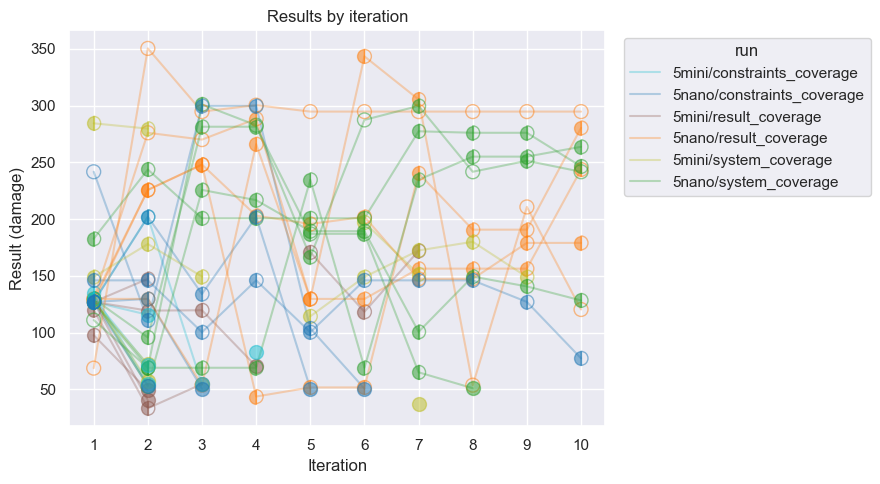

In [29]:
plot_df = plot_data.T.copy()  # index: result columns like `02_result`, columns: MultiIndex (llm, params, repeat)
orig_cols = plot_df.columns  # MultiIndex
labels = [f"{llm}/{params}/{repeat}" for llm, params, repeat in orig_cols]
x = list(range(1, len(plot_df.index) + 1))

fig, ax = plt.subplots(figsize=(9, 5))
for col, label in zip(orig_cols, labels):
    y = plot_df[col].values
    # draw the line for the run
    label_no_repeat = label.rsplit("/", 1)[0]
    # color = colors[label.rsplit("/", 1)[0].rsplit("_", 1)[0]]
    if label_no_repeat not in colors:
        continue

    color = colors[label_no_repeat]
    if label_no_repeat in ax.get_legend_handles_labels()[1]:
        label_no_repeat = None
    line, = ax.plot(x, y, '-', label=label_no_repeat, alpha=0.3, color=color)

    # collect indices by test status
    pass_idx, half_idx, fail_idx = [], [], []
    for i, result_col in enumerate(plot_df.index):  # e.g. '02_result'
        system_col = result_col.replace('_result', '_system')
        functional_col = result_col.replace('_result', '_functional')
        all_col = result_col.replace('_result', '_all')

        system = summary.loc[col, system_col]
        functional = summary.loc[col, functional_col] if functional_col in summary.columns else summary.loc[col, all_col]

        if system == "pass" and functional == "pass":
            pass_idx.append(i)
        elif system == "pass":
            half_idx.append(i)
        else:
            fail_idx.append(i)

    # overplot markers (use same color as the line)
    scatter_kwargs = {
        "zorder": 5 if "constraints" in label else 3,
        "s": 100, "alpha": 0.5
    }
    if pass_idx:
        ax.scatter([x[i] for i in pass_idx], [y[i] for i in pass_idx], marker='o', color=color, **scatter_kwargs)
    if half_idx:
        ax.scatter([x[i] for i in half_idx], [y[i] for i in half_idx], marker=MarkerStyle("o", fillstyle="left"), color=color, **scatter_kwargs)
        ax.scatter([x[i] for i in half_idx], [y[i] for i in half_idx], marker=MarkerStyle("o", fillstyle="right"), color="none", edgecolors=color, **scatter_kwargs)
    if fail_idx:
        ax.scatter([x[i] for i in fail_idx], [y[i] for i in fail_idx], marker='o', color=color, facecolors='none', **scatter_kwargs)

# finalize axes
ax.set_xticks(x)
ax.set_xticklabels(x)  # iterations 1,2,3,...
ax.set_xlabel("Iteration")
ax.set_ylabel("Result (damage)")
ax.set_title("Results by iteration")
ax.legend(title="run", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

### Iterations counts

In [30]:
def last_value_index(row):
    last_index = 0
    for i, col in enumerate(row.index, start=1):
        if not np.isnan(row[col]):
            last_index = i
    return last_index

iterations = plot_data.apply(last_value_index, axis=1)
iterations = pd.DataFrame(iterations).rename(columns={0: "iterations"})
iterations = iterations.reset_index()
iterations

,llm,params,repeat,iterations
0,5mini,constraints_coverage,01,2
1,5mini,constraints_coverage,02,4
2,5mini,constraints_coverage,03,2
3,5mini,constraints_coverage,04,2
4,5mini,constraints_coverage,05,3
5,5nano,constraints_coverage,01,10
6,5nano,constraints_coverage,02,2
7,5nano,constraints_coverage,03,5
8,5nano,constraints_coverage,04,6
9,5nano,constraints_coverage,05,3


<Axes: xlabel='iterations', ylabel='params'>

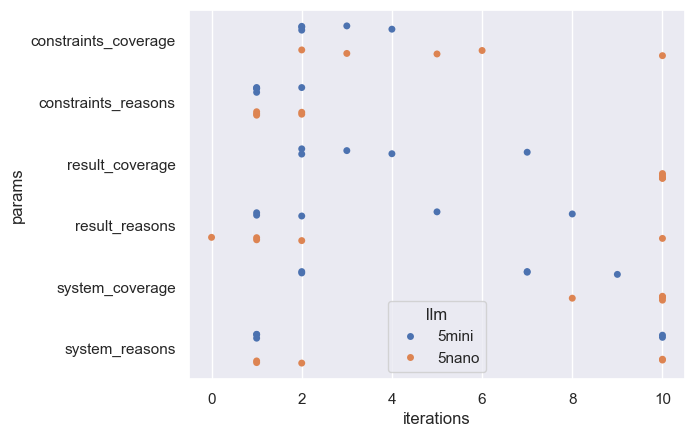

In [31]:
sns.stripplot(x="iterations", y="params", hue="llm", data=iterations, dodge=True)

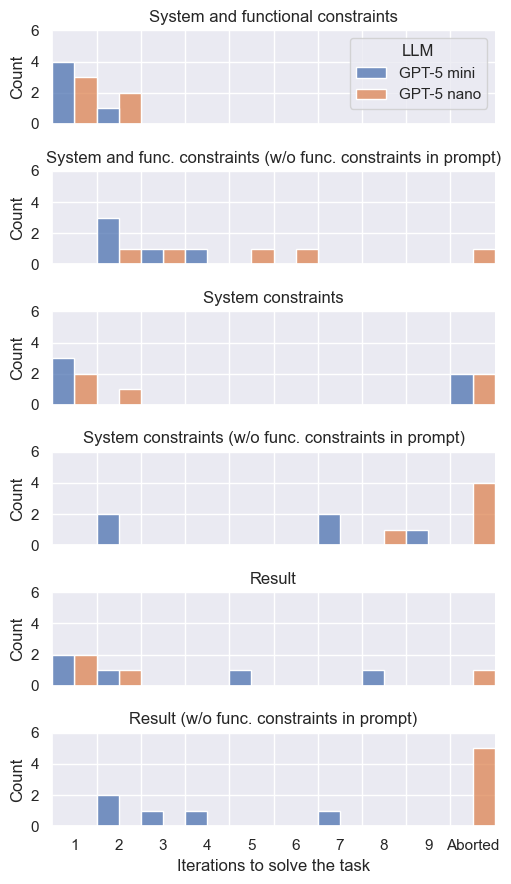

In [57]:
label_map = {
    "constraints_reasons": "System and functional constraints",
    "constraints_coverage": "System and func. constraints (w/o func. constraints in prompt)",
    "system_reasons": "System constraints",
    "system_coverage": "System constraints (w/o func. constraints in prompt)",
    "result_reasons": "Result",
    "result_coverage": "Result (w/o func. constraints in prompt)",
}
llm_map = {
    "5nano": "GPT-5 nano",
    "5mini": "GPT-5 mini",
}
iterations["params_label"] = iterations["params"].map(label_map)
iterations["llm_label"] = iterations["llm"].map(llm_map)

g = sns.displot(iterations, x="iterations", hue="llm_label", row="params_label", multiple="dodge", bins=np.arange(0.5, 11, 1), height=1.5, aspect=3.5, facet_kws={"legend_out": False, "xlim": (0.5, 10.5)}, row_order=list(label_map.values()))
for ax in g.axes.flatten():
    ax.set_xticks(range(1, 11), labels=list(range(1, 10)) + ["Aborted"])
    ax.set_yticks(range(0, 7, 2))

    # minor ticks for grid lines between bars
    ax.xaxis.set_minor_locator(FixedLocator(np.arange(1.5, 10.5, 1)))
    ax.tick_params(axis='x', which='minor', length=0)
    ax.grid(False, which='major', axis='x')
    ax.grid(True, which='minor', axis='x')

g.set_titles(row_template="{row_name}")
g.set_xlabels("Iterations to solve the task")
g._legend.set_title("LLM")

g.tight_layout()
plt.savefig(results_folder / "farm_hist.pdf", bbox_inches="tight")
plt.show()